# Model Evaluation & Visualisation

**In this notebook:**
1. Setup --> models, loaders, helpers
2. Full evaluation --> DICE / HD95 / Precision / Recall for all 3 methods (Classical seg, Baseline, Guided U-Net)
3. By-index viewer --> inspect any case from train or test
4. Greatest guided improvement over baseline
5. Best / median / worst per model
6. Presentation grid — all models on the same 3 cases
7. Per-site breakdown

## 0. Setup

In [2]:
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from tqdm.auto import tqdm

from monai.transforms import Compose, LoadImaged, EnsureChannelFirstd, EnsureTyped
from monai.inferers import sliding_window_inference

# TODO: Change to your own repo path
REPO_ROOT  = Path('/data/users/ssethi2/mmml_repos/guided-brightspot')
sys.path.insert(0, str(REPO_ROOT))

In [3]:
from evaluation.metrics import evaluate_case
from training.dataset   import PATCH_SIZE
from training.models    import build_baseline, build_guided

CKPT_DIR    = REPO_ROOT / 'outputs' / 'checkpoints'
OUT_DIR     = REPO_ROOT / 'outputs' / 'evaluation'
PROC_TRAIN  = REPO_ROOT / 'data' / 'processed' / 'training'
PROC_TEST   = REPO_ROOT / 'data' / 'processed' / 'test'
OUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SPACING     = (1.0, 1.0, 3.0)
SW_BATCH    = 2
TRAIN_SITES = ['Utrecht', 'Singapore', 'Amsterdam/GE3T']
TEST_SITES  = ['Utrecht', 'Singapore', 'Amsterdam/GE3T',
               'Amsterdam/GE1T5', 'Amsterdam/Philips_VU .PETMR_01.']
COL = {'guided': '#DD8452', 'baseline': '#4C72B0', 'classical': '#55A868'}

print(f'Device: {DEVICE}')

Device: cuda


In [4]:
# ── Case discovery ────────────────────────────────────────────────────────────
def discover_cases(split):
    root  = PROC_TRAIN if split == 'training' else PROC_TEST
    sites = TRAIN_SITES if split == 'training' else TEST_SITES
    cases = []
    for site in sites:
        sdir = root / site
        if not sdir.exists():
            continue
        for pdir in sorted(sdir.iterdir(), key=lambda x: x.name):
            if not (pdir / 'FLAIR.nii').exists():
                continue
            cases.append({
                'split':    split,  'site': site,  'pid': pdir.name,
                'flair':    pdir / 'FLAIR.nii',
                't1':       pdir / 'T1.nii',
                'wmh':      pdir / 'wmh.nii',
                'soft_map': pdir / 'soft_map.nii',
                'cls_seg':  pdir / 'classical_seg.nii',
            })
    return cases

train_cases = discover_cases('training')
test_cases  = discover_cases('test')
print(f'Training cases: {len(train_cases)}')
print(f'Test cases:     {len(test_cases)}')

Training cases: 60
Test cases:     110


In [5]:
# ── MONAI loader — guarantees (H, W, D) axis order matching training ──────────
_ALL_KEYS = ['flair', 't1', 'wmh', 'soft_map', 'cls_seg']
_FLT_KEYS = ['flair', 't1', 'soft_map']

_loader = Compose([
    LoadImaged(keys=_ALL_KEYS, image_only=True, ensure_channel_first=False),
    EnsureChannelFirstd(keys=_ALL_KEYS),
    EnsureTyped(keys=_FLT_KEYS, dtype=torch.float32),
])

def load_case_arrays(case):
    """
    Load all arrays for one case using MONAI (same axis order as training).
    For missing files (e.g. no GT on test set), returns None.
    All arrays are (H, W, D) with channel dim squeezed out.
    """
    # For missing files, duplicate FLAIR as a dummy (we return None for them)
    flair_str = str(case['flair'])
    d = _loader({
        'flair':    flair_str,
        't1':       str(case['t1']),
        'wmh':      str(case['wmh'])      if case['wmh'].exists()      else flair_str,
        'soft_map': str(case['soft_map']) if case['soft_map'].exists() else flair_str,
        'cls_seg':  str(case['cls_seg'])  if case['cls_seg'].exists()  else flair_str,
    })
    flair = d['flair'].squeeze(0).numpy().astype(np.float32)
    t1    = d['t1'].squeeze(0).numpy().astype(np.float32)
    gt    = d['wmh'].squeeze(0).numpy().astype(np.uint8)        if case['wmh'].exists()      else None
    soft  = d['soft_map'].squeeze(0).numpy().astype(np.float32) if case['soft_map'].exists() else np.zeros_like(flair)
    cls   = d['cls_seg'].squeeze(0).numpy().astype(np.uint8)    if case['cls_seg'].exists()  else None
    return flair, t1, gt, soft, cls

# ── Axis-order sanity check ───────────────────────────────────────────────────
flair, t1, gt, soft, cls = load_case_arrays(train_cases[0])
print(f'FLAIR shape: {flair.shape}  ← must be (200, 200, 48)')
assert flair.shape == (200, 200, 48), \
    f'Axis mismatch! Got {flair.shape}. Check loader.'
print('Axis order OK.')

FLAIR shape: (200, 200, 48)  ← must be (200, 200, 48)
Axis order OK.


In [6]:
# ── Load model checkpoints ────────────────────────────────────────────────────
def load_model(model_fn, ckpt_name):
    model = model_fn().to(DEVICE)
    ckpt  = torch.load(CKPT_DIR / ckpt_name, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    print(f'  {ckpt_name}: epoch={ckpt["epoch"]+1}, '
          f'best val DICE={ckpt["best_metric"]:.4f}')
    return model

print('Loading checkpoints...')
baseline_model = load_model(build_baseline, 'baseline_best.pt')
guided_model   = load_model(build_guided,   'guided_best.pt')

Loading checkpoints...


  baseline_best.pt: epoch=275, best val DICE=0.6252
  guided_best.pt: epoch=255, best val DICE=0.6825


In [7]:
# ── Inference + display helpers ───────────────────────────────────────────────
def predict_volume(model, flair, t1, soft, model_type):
    """Sliding window inference on a (H, W, D) volume. Returns (H, W, D) uint8."""
    x  = torch.cat([
        torch.tensor(flair[None, None]).float().to(DEVICE),
        torch.tensor(t1[None, None]).float().to(DEVICE),
    ], dim=1)
    sm = torch.tensor(soft[None, None]).float().to(DEVICE)

    with torch.no_grad():
        if model_type == 'guided':
            def _fwd(patch):
                sm_p = F.interpolate(sm, size=patch.shape[2:],
                                     mode='trilinear', align_corners=False)
                return model(patch, sm_p)
        else:
            def _fwd(patch): return model(patch)

        logits = sliding_window_inference(x, PATCH_SIZE, SW_BATCH, _fwd, overlap=0.25)

    return torch.argmax(logits, dim=1).squeeze(0).cpu().numpy().astype(np.uint8)

def normalize_display(arr):
    mn, mx = arr.min(), arr.max()
    return (arr - mn) / (mx - mn + 1e-8)

def best_slice(arr):
    """Axial slice index with most foreground from (H, W, D) array."""
    counts = arr.sum(axis=(0, 1))   # sum over H, W → (D,)
    idx    = int(counts.argmax())
    return idx if counts[idx] > 0 else arr.shape[2] // 2

def sl2d(arr, sl):
    """2-D axial slice from (H, W, D) array."""
    return arr[:, :, sl]

def overlay(ax, f2d, mask2d, color, alpha=0.65):
    ax.imshow(f2d, cmap='gray')
    if mask2d is not None and mask2d.max() > 0:
        rgba    = np.zeros((*mask2d.shape, 4))
        c       = plt.cm.colors.to_rgba(color)
        rgba[mask2d > 0] = (*c[:3], alpha)
        ax.imshow(rgba)

def vdice(pred2d, gt2d):
    inter = (pred2d * gt2d).sum()
    return float(2 * inter / (pred2d.sum() + gt2d.sum() + 1e-6))

## 1. Full evaluation

In [8]:
def evaluate_all(cases, desc='Evaluating'):
    rows = []
    for case in tqdm(cases, desc=desc):
        if not case['wmh'].exists():
            continue
        flair, t1, gt, soft, cls = load_case_arrays(case)
        base = dict(split=case['split'], site=case['site'], pid=case['pid'])

        if cls is not None:
            rows.append({**base, 'method': 'classical',
                         **evaluate_case(cls, gt, spacing=SPACING)})

        bl_pred = predict_volume(baseline_model, flair, t1, soft, 'baseline')
        rows.append({**base, 'method': 'baseline',
                     **evaluate_case(bl_pred, gt, spacing=SPACING)})

        gu_pred = predict_volume(guided_model, flair, t1, soft, 'guided')
        rows.append({**base, 'method': 'guided',
                     **evaluate_case(gu_pred, gt, spacing=SPACING)})

    return pd.DataFrame(rows)

train_df = evaluate_all(train_cases, desc='Training set')

has_test_gt = any(c['wmh'].exists() for c in test_cases)
test_df     = evaluate_all(test_cases, desc='Test set') if has_test_gt \
              else pd.DataFrame()
if not has_test_gt:
    print('No test GT found — skipping test evaluation.')

train_df.to_csv(OUT_DIR / 'train_eval.csv', index=False)
if not test_df.empty:
    test_df.to_csv(OUT_DIR / 'test_eval.csv', index=False)
print('Done. CSVs saved to', OUT_DIR)

Training set:   0%|          | 0/60 [00:00<?, ?it/s]Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
Test set: 100%|██████████| 110/110 [04:08<00:00,  2.26s/it]

Done. CSVs saved to /data/users/ssethi2/mmml_repos/guided-brightspot/outputs/evaluation


In [9]:
def summary_table(df, label):
    if df.empty: return
    print(f'\n{label}')
    print('='*72)
    print(f"{'Method':<12} {'N':>4} {'DICE mean':>10} {'DICE std':>9} "
          f"{'DICE max':>9} {'HD95 mean':>10} {'Precision':>10} {'Recall':>8}")
    print('-'*72)
    for m in ['classical', 'baseline', 'guided']:
        sub = df[df['method'] == m]
        if sub.empty: continue
        hd  = sub['hausdorff95'].replace([np.inf], np.nan).dropna()
        print(f"{m:<12} {len(sub):>4} "
              f"{sub['dice'].mean():>10.4f} "
              f"{sub['dice'].std():>9.4f} "
              f"{sub['dice'].max():>9.4f} "
              f"{hd.mean():>10.2f} "
              f"{sub['precision'].mean():>10.4f} "
              f"{sub['recall'].mean():>8.4f}")

summary_table(train_df, 'TRAINING SET')
summary_table(test_df,  'TEST SET')


TRAINING SET
Method          N  DICE mean  DICE std  DICE max  HD95 mean  Precision   Recall
------------------------------------------------------------------------
classical      60     0.1457    0.1983    0.7460      49.47     0.0426   0.0190
baseline       60     0.6985    0.1379    0.8860      10.11     0.6680   0.1796
guided         60     0.7338    0.0970    0.8699       6.56     0.6404   0.3482

TEST SET
Method          N  DICE mean  DICE std  DICE max  HD95 mean  Precision   Recall
------------------------------------------------------------------------
classical     110     0.1765    0.2275    0.7915      49.10     0.0666   0.0267
baseline      110     0.6390    0.1431    0.8591      10.88     0.5763   0.1628
guided        110     0.6936    0.1240    0.8690       7.93     0.6007   0.3277


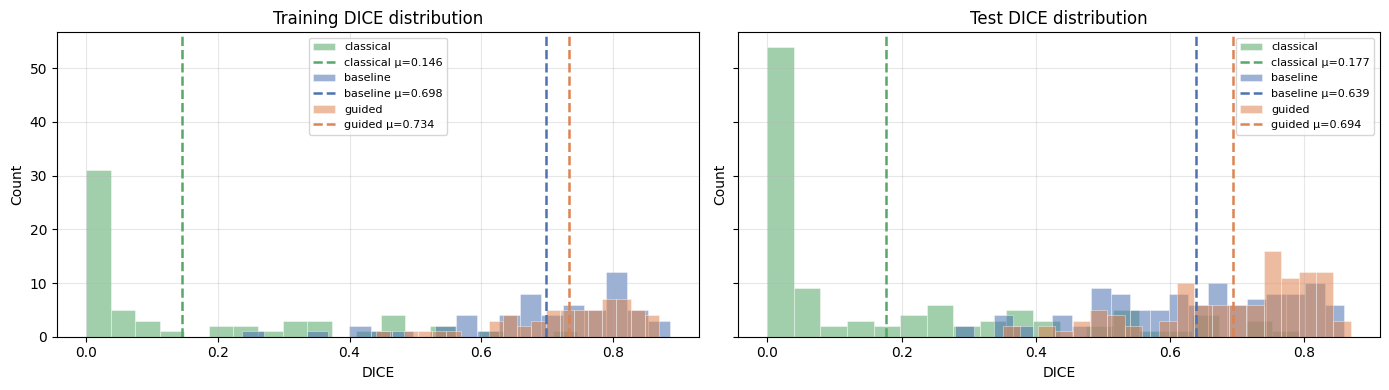

In [ ]:
active = [(train_df,'Training')] + ([(test_df,'Test')] if not test_df.empty else [])
fig, axes = plt.subplots(1, len(active), figsize=(7*len(active), 4), sharey=True)
if len(active) == 1: axes = [axes]

for ax, (df, label) in zip(axes, active):
    for m in ['classical','baseline','guided']:
        sub = df[df['method']==m]['dice']
        ax.hist(sub, bins=20, alpha=0.55, color=COL[m], label=m,
                edgecolor='white', linewidth=0.5)
        ax.axvline(sub.mean(), color=COL[m], linestyle='--', linewidth=1.8,
                   label=f'{m} μ={sub.mean():.3f}')
    ax.set_title(f'{label} DICE distribution')
    ax.set_xlabel('DICE'); ax.set_ylabel('Count')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
#plt.savefig(OUT_DIR/'dice_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. By-index viewer

training case 1: Utrecht/11


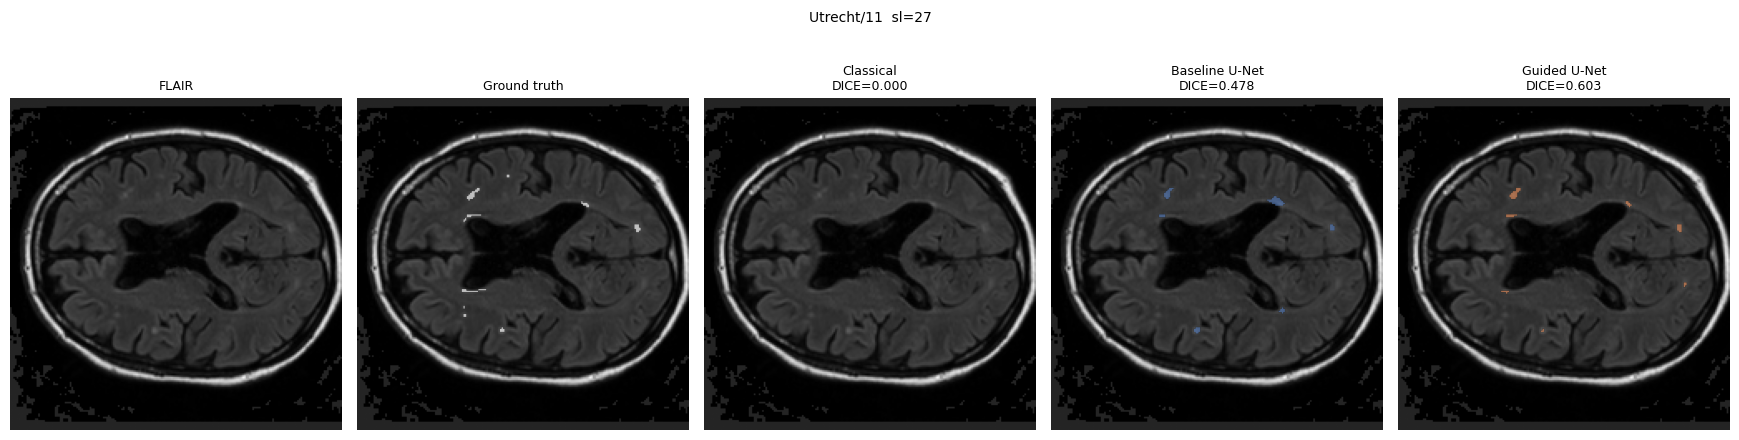

In [10]:
def show_case(case, slice_idx=None, save_path=None,
              bl_dice_override=None, gu_dice_override=None):
    flair, t1, gt, soft, cls = load_case_arrays(case)
    bl  = predict_volume(baseline_model, flair, t1, soft, 'baseline')
    gu  = predict_volume(guided_model,   flair, t1, soft, 'guided')
    ref = gt if gt is not None else bl
    s   = slice_idx if slice_idx is not None else best_slice(ref)
    f2d = normalize_display(sl2d(flair, s))

    def dtitle(mask, name, override=None):
        if gt is None: return name
        d = override if override is not None else vdice(sl2d(mask, s), sl2d(gt, s))
        return f'{name}\nDICE={d:.3f}'

    panels = [('FLAIR', None, None)]
    if gt  is not None: panels.append(('Ground truth', gt, 'white'))
    if cls is not None: panels.append((dtitle(cls, 'Classical'), cls, COL['classical']))
    panels.append((dtitle(bl, 'Baseline U-Net', bl_dice_override), bl, COL['baseline']))
    panels.append((dtitle(gu, 'Guided U-Net',   gu_dice_override), gu, COL['guided']))

    fig, axes = plt.subplots(1, len(panels), figsize=(3.5*len(panels), 5))
    for ax, (title, mask, color) in zip(axes, panels):
        if mask is None: ax.imshow(f2d, cmap='gray')
        else: overlay(ax, f2d, sl2d(mask, s), color)
        ax.set_title(title, fontsize=9); ax.axis('off')

    fig.suptitle(f"{case['site'].split('/')[-1]}/{case['pid']}  sl={s}", fontsize=10)
    plt.tight_layout()
    if save_path: fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    return fig

# ── TODO: Change idx / split to inspect any case ────────────────────────────────────
split = 'training'
idx   = 1
cases = train_cases if split == 'training' else test_cases
print(f'{split} case {idx}: {cases[idx]["site"]}/{cases[idx]["pid"]}')
_ = show_case(cases[idx])

## 3. Greatest guided improvement over baseline

Top 10 — guided most outperforms baseline (training):
          site pid     bl     gu  delta
       Utrecht   8 0.2375 0.4397 0.2022
       Utrecht   6 0.3398 0.5078 0.1680
Amsterdam/GE3T 102 0.4717 0.6120 0.1403
Amsterdam/GE3T 144 0.4122 0.5347 0.1225
       Utrecht  11 0.4354 0.5533 0.1179
Amsterdam/GE3T 100 0.5435 0.6552 0.1117
Amsterdam/GE3T 137 0.5782 0.6836 0.1054
     Singapore  53 0.4120 0.5025 0.0905
       Utrecht  49 0.6611 0.7500 0.0889
       Utrecht  17 0.6117 0.6996 0.0879

Bottom 5 — baseline beats guided:
     site pid     bl     gu   delta
Singapore  57 0.8069 0.7554 -0.0515
Singapore  60 0.8765 0.8219 -0.0546
Singapore  59 0.8119 0.7539 -0.0580
Singapore  68 0.7855 0.7049 -0.0806
Singapore  67 0.7390 0.6349 -0.1041

Visualising: Utrecht/8  baseline=0.2375 → guided=0.4397  Δ=+0.2022


Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)


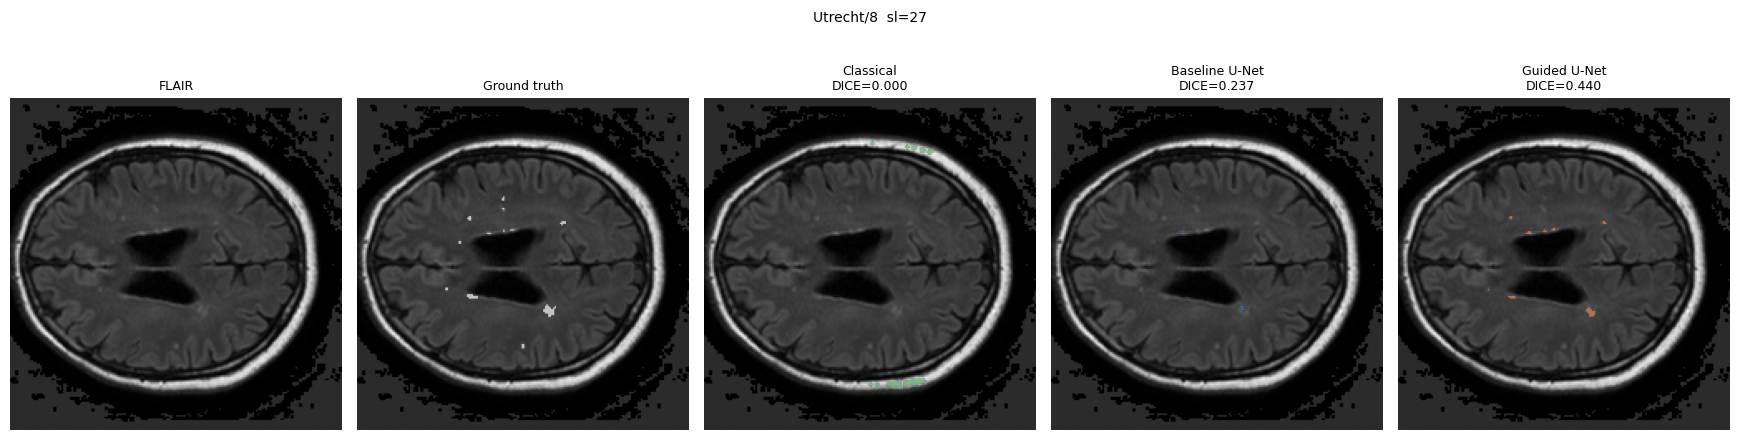

In [11]:
def show_greatest_improvement(df, cases_list, split='training'):
    sub  = df[df['split'] == split]
    bl   = sub[sub['method']=='baseline'][['site','pid','dice']].rename(columns={'dice':'bl'})
    gu   = sub[sub['method']=='guided'][['site','pid','dice']].rename(columns={'dice':'gu'})
    mrg  = bl.merge(gu, on=['site','pid'])
    mrg['delta'] = (mrg['gu'] - mrg['bl']).round(4)
    mrg  = mrg.sort_values('delta', ascending=False).reset_index(drop=True)

    print(f'Top 10 — guided most outperforms baseline ({split}):')
    print(mrg.head(10).to_string(index=False))
    print(f'\nBottom 5 — baseline beats guided:')
    print(mrg.tail(5).to_string(index=False))

    best = mrg.iloc[0]
    case = next(c for c in cases_list
                if c['site']==best['site'] and c['pid']==best['pid'])
    print(f"\nVisualising: {case['site']}/{case['pid']}  "
          f"baseline={best['bl']:.4f} → guided={best['gu']:.4f}  Δ={best['delta']:+.4f}")
    _ = show_case(case,
                  bl_dice_override=float(best['bl']),
                  gu_dice_override=float(best['gu']),
                  save_path=OUT_DIR/f'greatest_improvement_{split}.png')
    return mrg

improvement_df = show_greatest_improvement(train_df, train_cases)

## 4. Best / median / worst per model

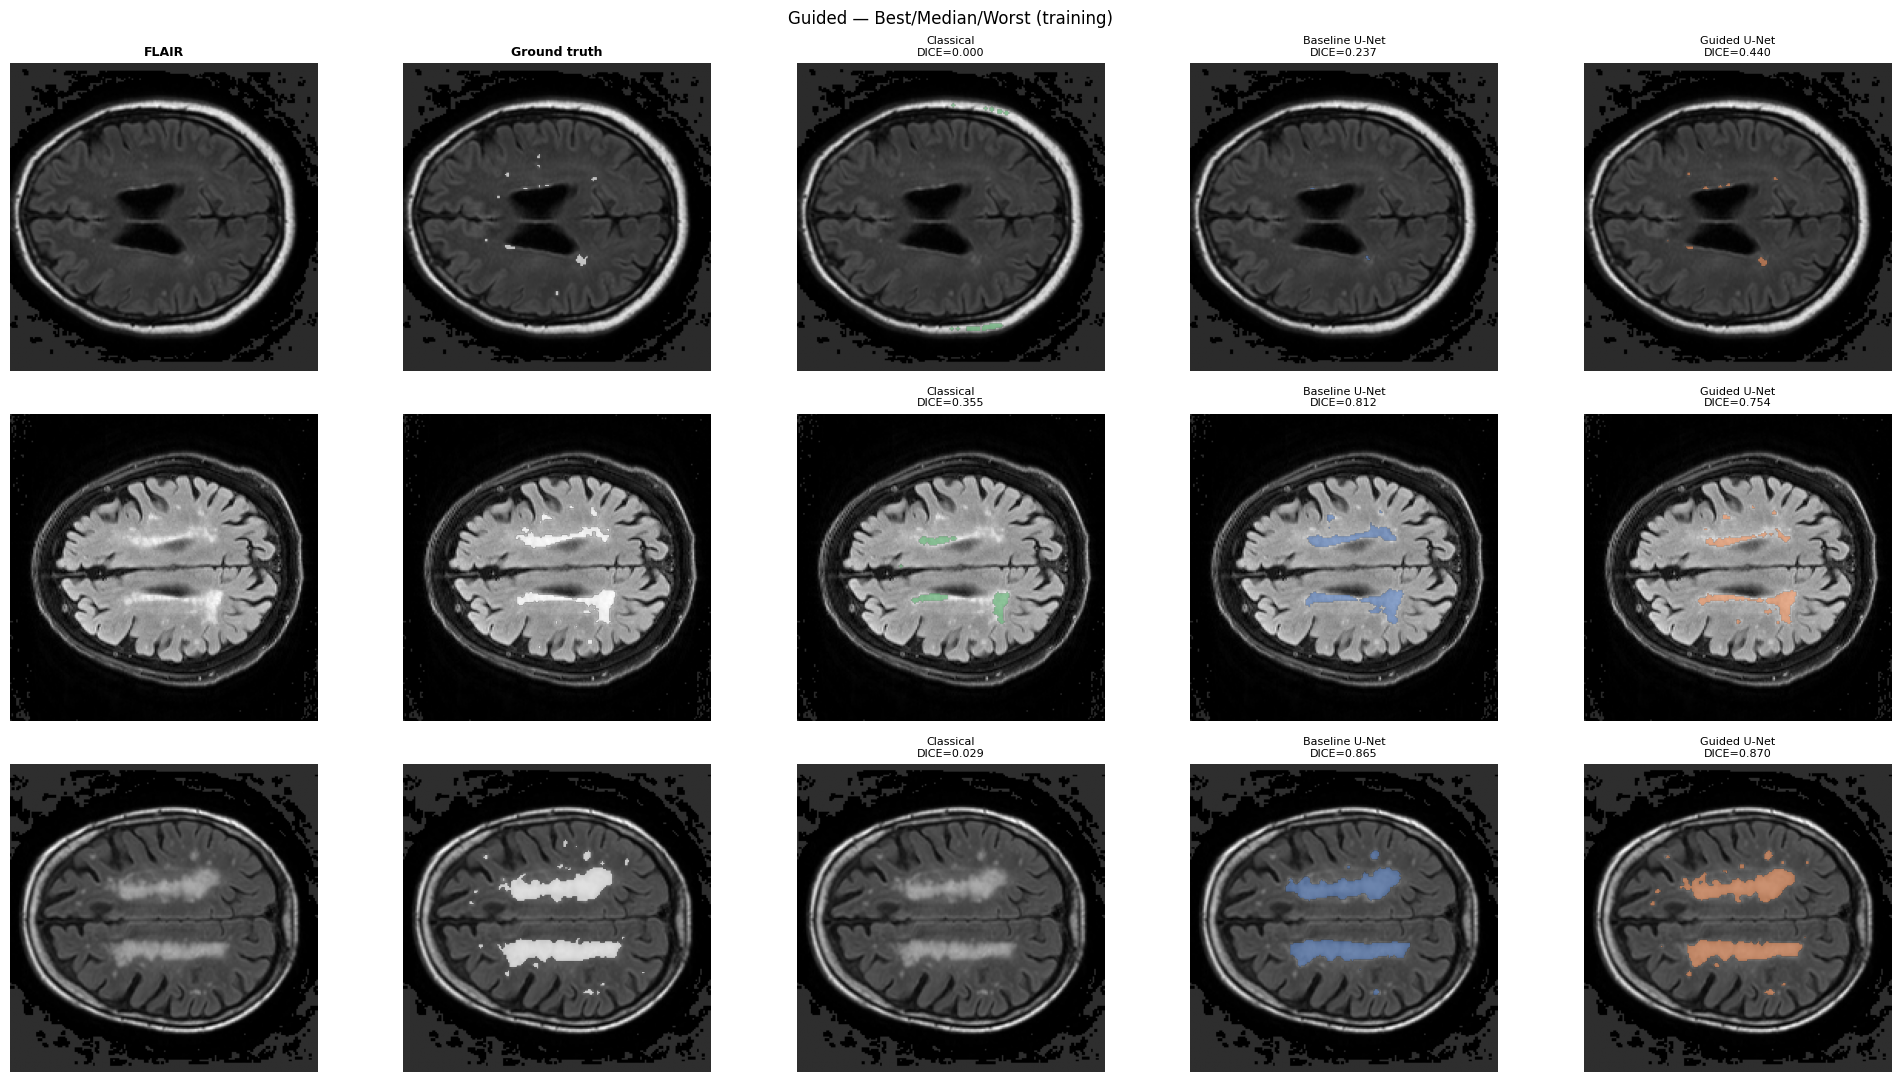

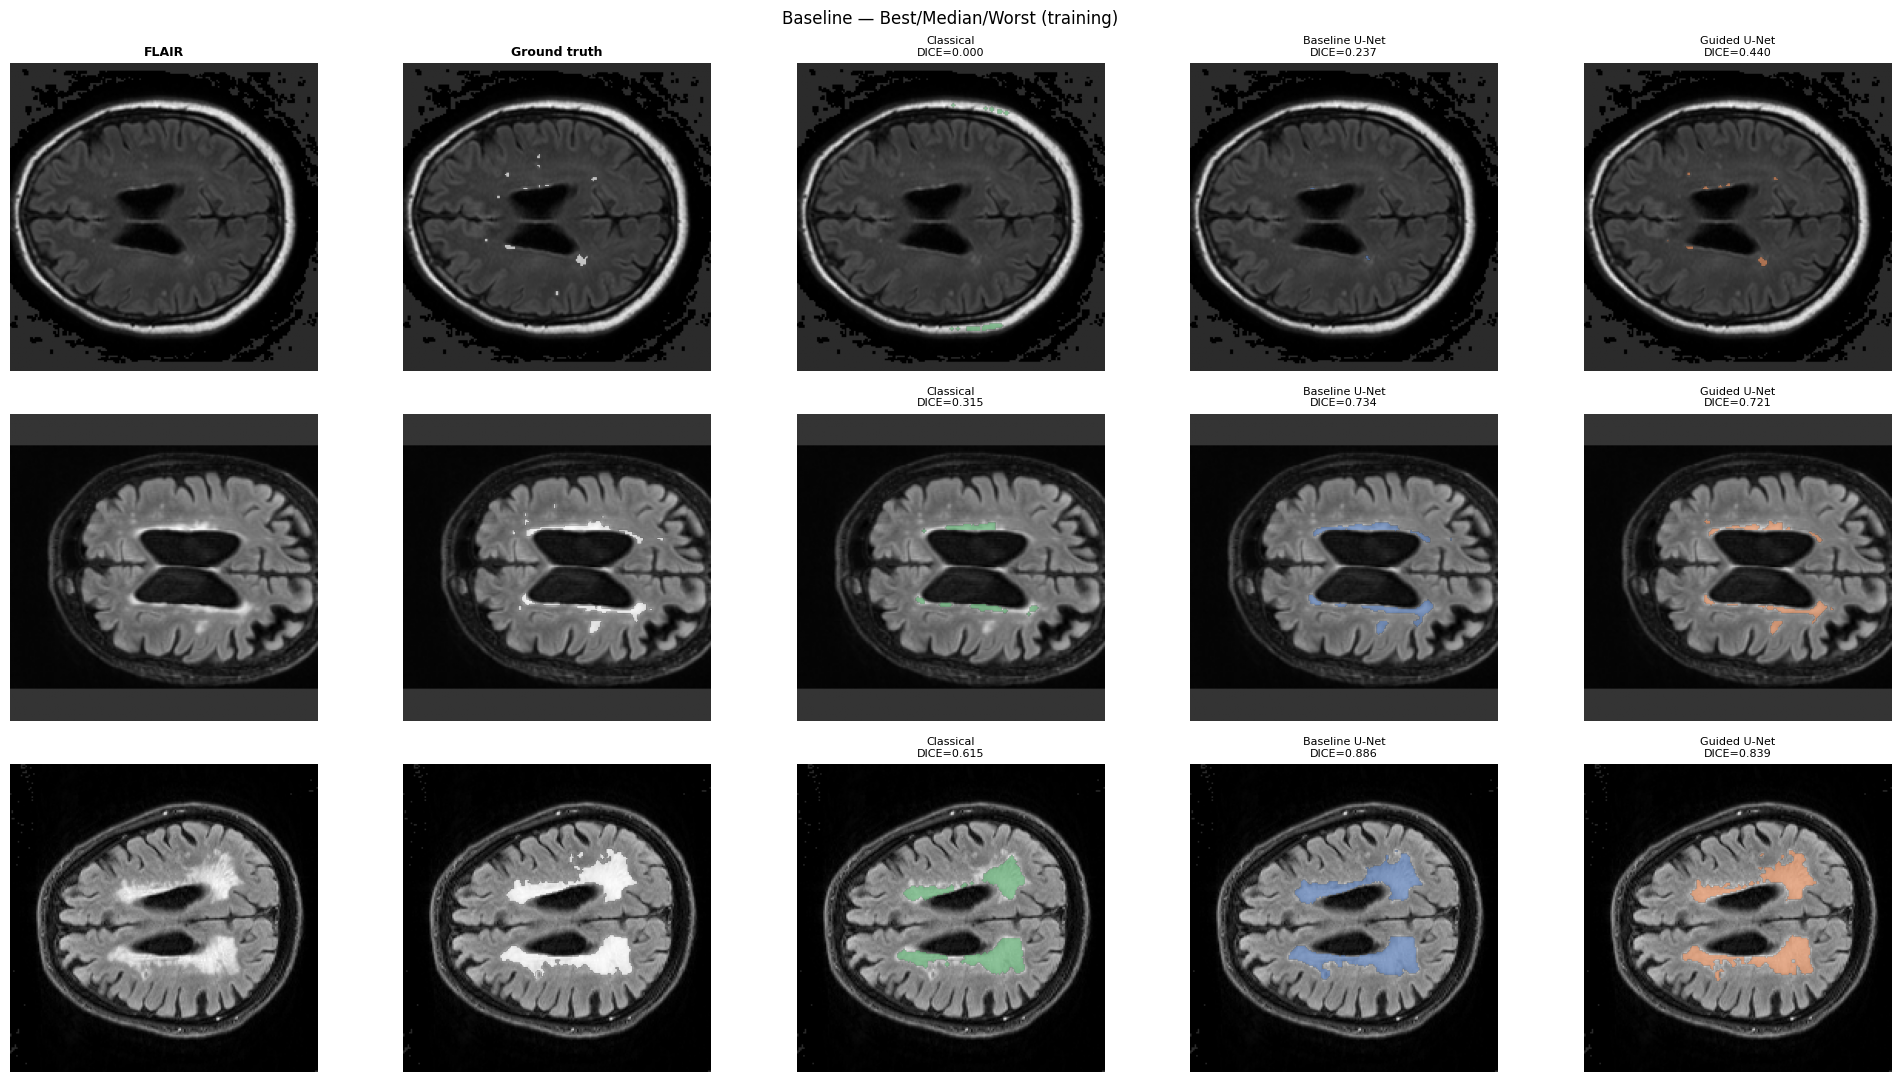

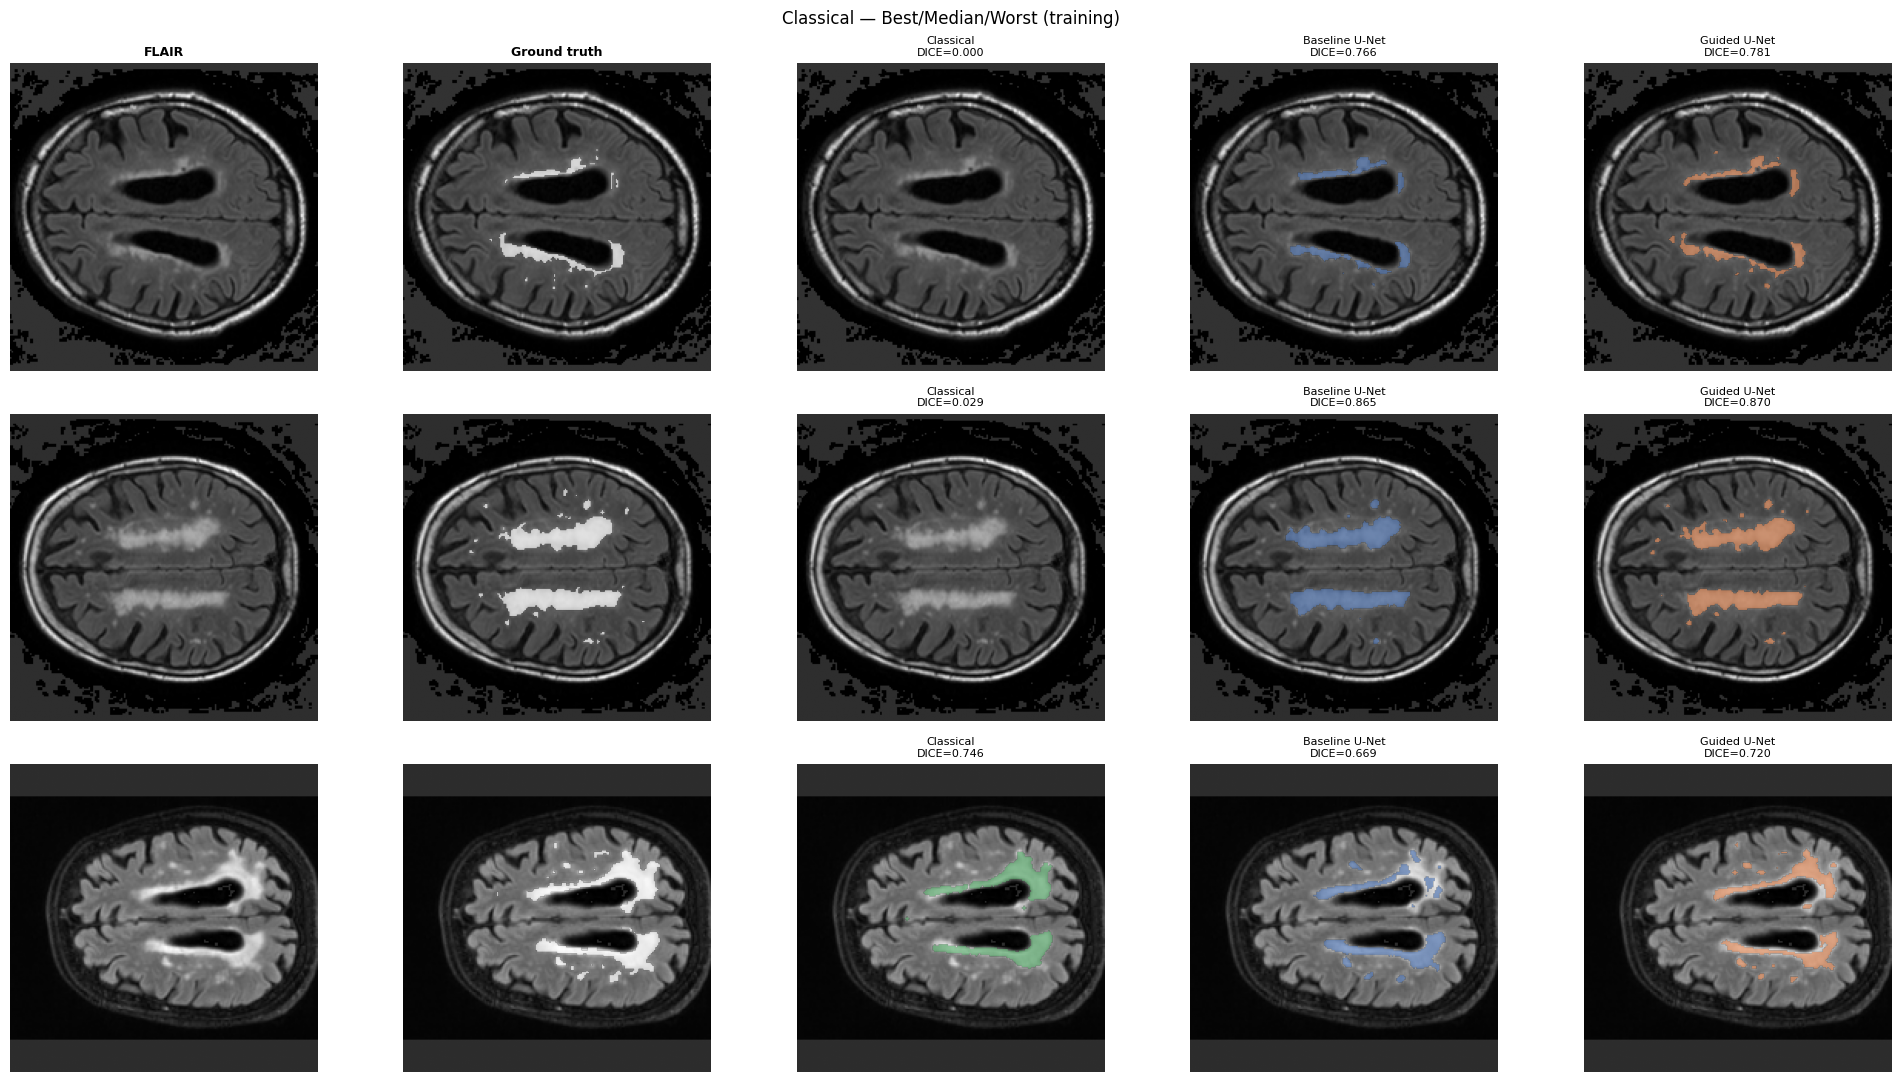

In [13]:

def show_bmw(df, cases_list, method, split='training'):
    sub  = df[(df['method']==method) & (df['split']==split)].sort_values('dice')
    n    = len(sub)
    picks = [
        (f'Worst  DICE={sub.iloc[0]["dice"]:.3f}',    sub.iloc[0]),
        (f'Median DICE={sub.iloc[n//2]["dice"]:.3f}', sub.iloc[n//2]),
        (f'Best   DICE={sub.iloc[-1]["dice"]:.3f}',   sub.iloc[-1]),
    ]
    col_labels = ['FLAIR', 'Ground truth', 'Classical', 'Baseline U-Net', 'Guided U-Net']
    col_colors = [None, 'white', COL['classical'], COL['baseline'], COL['guided']]
    # Maps col_index → method name for looking up stored DICE
    col_methods = [None, None, 'classical', 'baseline', 'guided']

    fig, axes = plt.subplots(3, 5, figsize=(20, 11))
    for row_i, (row_label, row_data) in enumerate(picks):
        case = next(c for c in cases_list
                    if c['site']==row_data['site'] and c['pid']==row_data['pid'])
        flair, t1, gt, soft, cls = load_case_arrays(case)
        bl  = predict_volume(baseline_model, flair, t1, soft, 'baseline')
        gu  = predict_volume(guided_model,   flair, t1, soft, 'guided')
        s   = best_slice(gt) if gt is not None else flair.shape[2]//2
        f2d = normalize_display(sl2d(flair, s))
        masks = [None, gt, cls, bl, gu]

        # Look up stored volume DICE for this case from df
        def get_stored_dice(col_method):
            if col_method is None: return None
            row = df[(df['method']==col_method) &
                     (df['site']==row_data['site']) &
                     (df['pid']==row_data['pid'])]
            return float(row['dice'].values[0]) if len(row) > 0 else None

        for col_i, (mask, color) in enumerate(zip(masks, col_colors)):
            ax = axes[row_i][col_i]
            if mask is None: ax.imshow(f2d, cmap='gray')
            else: overlay(ax, f2d, sl2d(mask, s), color)

            col_m = col_methods[col_i]
            if col_m is not None and gt is not None:
                # Use stored volume DICE — matches what the row label reports
                stored_d = get_stored_dice(col_m)
                title = f'{col_labels[col_i]}\nDICE={stored_d:.3f}' \
                        if stored_d is not None else col_labels[col_i]
                ax.set_title(title, fontsize=8)
            elif row_i == 0:
                ax.set_title(col_labels[col_i], fontsize=9, fontweight='bold')

            if col_i == 0:
                ax.set_ylabel(
                    f'{row_label}\n{case["site"].split("/")[-1]}/{case["pid"]}',
                    fontsize=8)
            ax.axis('off')

    fig.suptitle(f'{method.capitalize()} — Best/Median/Worst ({split})', fontsize=12)
    plt.tight_layout()
    #fig.savefig(OUT_DIR/f'bmw_{method}_{split}.png', dpi=150, bbox_inches='tight')
    plt.show()

show_bmw(train_df, train_cases, 'guided')
show_bmw(train_df, train_cases, 'baseline')
show_bmw(train_df, train_cases, 'classical')

## 5. Presentation grid

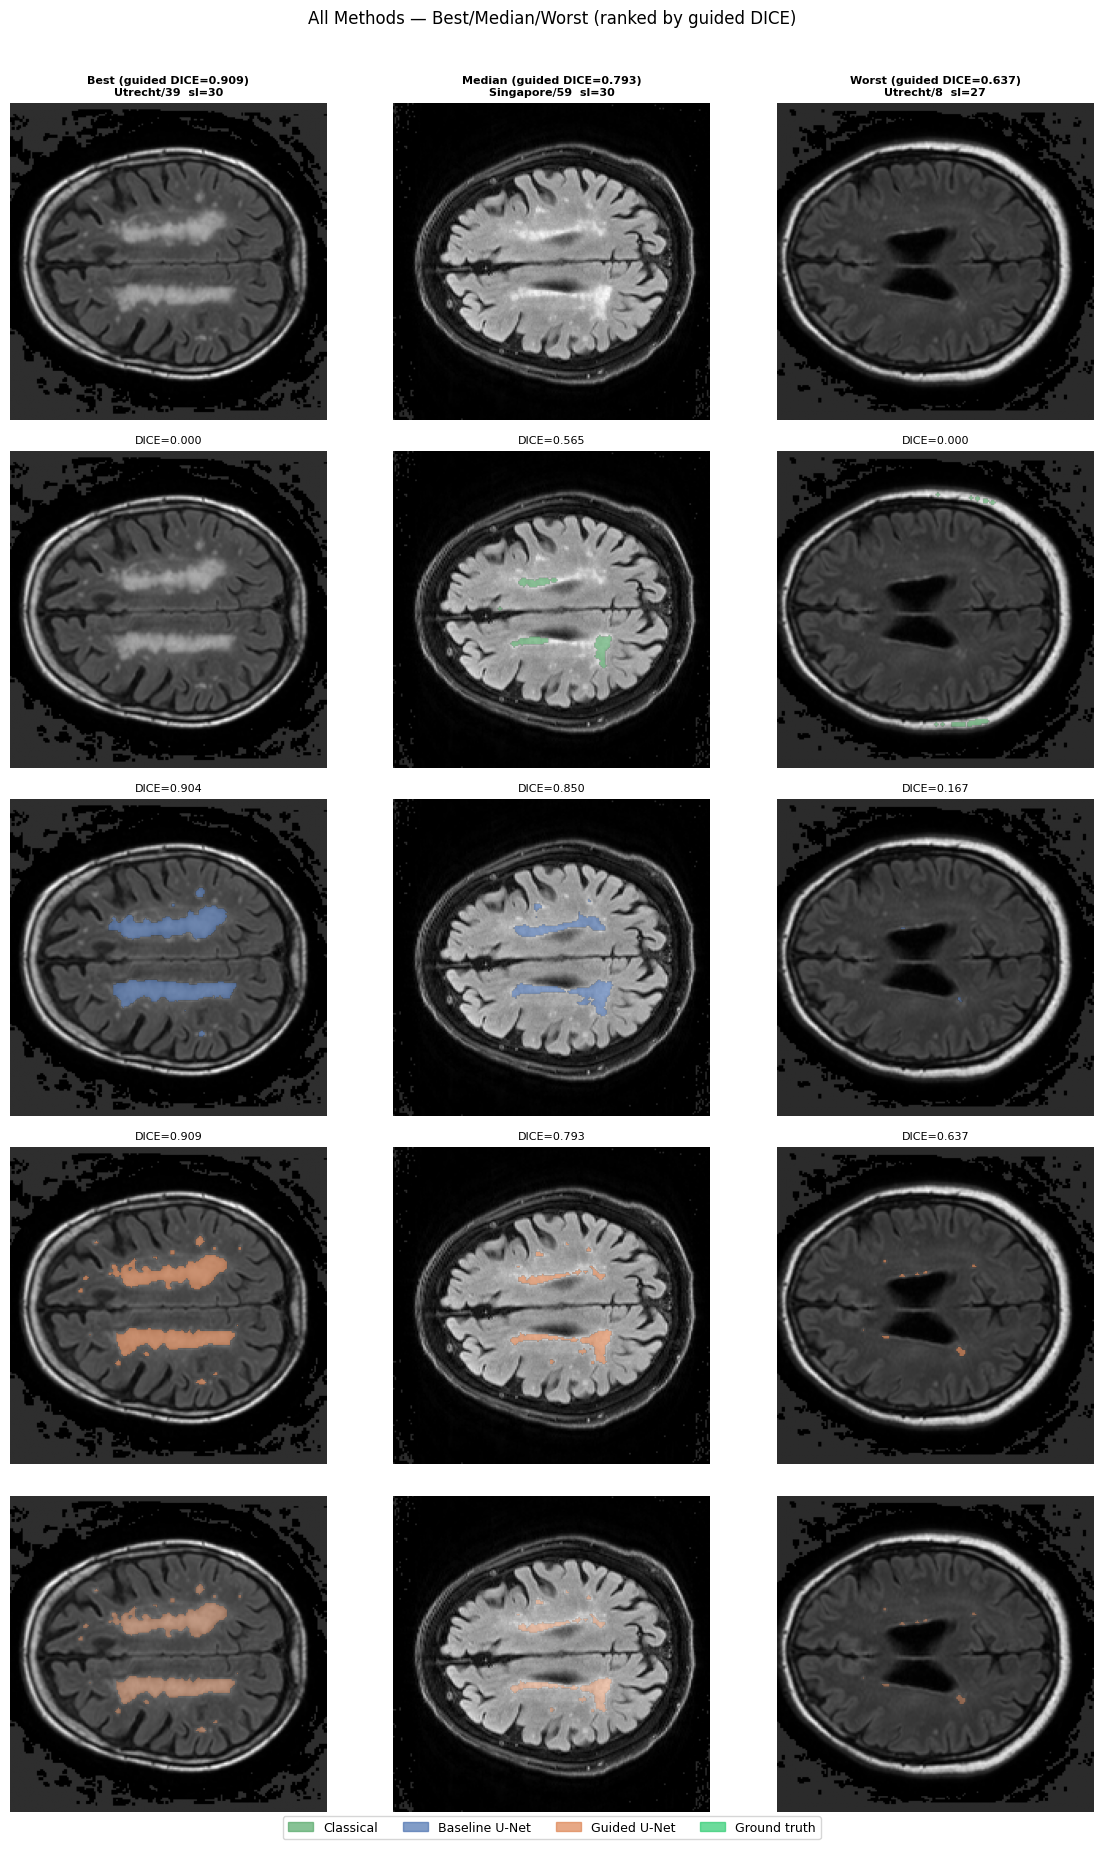

In [14]:
def presentation_grid(df, cases_list, split='training'):
    gu_sub = df[(df['method']=='guided') & (df['split']==split)].sort_values('dice')
    n = len(gu_sub)
    tiers  = [('Best', gu_sub.iloc[-1]), ('Median', gu_sub.iloc[n//2]),
               ('Worst', gu_sub.iloc[0])]
    row_labels = ['FLAIR','Classical','Baseline U-Net','Guided U-Net',
                  'GT (green) vs Guided (orange)']

    fig, axes = plt.subplots(5, 3, figsize=(12, 18))

    for col_i, (tier, row_data) in enumerate(tiers):
        case = next(c for c in cases_list
                    if c['site']==row_data['site'] and c['pid']==row_data['pid'])
        flair, t1, gt, soft, cls = load_case_arrays(case)
        bl  = predict_volume(baseline_model, flair, t1, soft, 'baseline')
        gu  = predict_volume(guided_model,   flair, t1, soft, 'guided')
        s   = best_slice(gt) if gt is not None else flair.shape[2]//2
        f2d = normalize_display(sl2d(flair, s))

        def ds(m): return f'DICE={vdice(sl2d(m,s),sl2d(gt,s)):.3f}' if gt is not None else ''

        axes[0][col_i].set_title(
            f'{tier} (guided {ds(gu)})\n{case["site"].split("/")[-1]}/{case["pid"]}  sl={s}',
            fontsize=8, fontweight='bold')

        axes[0][col_i].imshow(f2d, cmap='gray')

        axes[1][col_i].imshow(f2d, cmap='gray')
        if cls is not None:
            overlay(axes[1][col_i], f2d, sl2d(cls,s), COL['classical'])
            axes[1][col_i].set_title(ds(cls), fontsize=8)
        else:
            axes[1][col_i].set_title('N/A', fontsize=8)

        overlay(axes[2][col_i], f2d, sl2d(bl,s),  COL['baseline'])
        axes[2][col_i].set_title(ds(bl), fontsize=8)

        overlay(axes[3][col_i], f2d, sl2d(gu,s),  COL['guided'])
        axes[3][col_i].set_title(ds(gu), fontsize=8)

        axes[4][col_i].imshow(f2d, cmap='gray')
        if gt is not None:
            overlay(axes[4][col_i], f2d, sl2d(gt,s), '#2ECC71', alpha=0.55)
        overlay(axes[4][col_i], f2d, sl2d(gu,s), COL['guided'], alpha=0.45)

    for row_i, label in enumerate(row_labels):
        axes[row_i][0].set_ylabel(label, fontsize=9, fontweight='bold')
    for ax in axes.flat:
        ax.axis('off')

    handles = [
        mpatches.Patch(color=COL['classical'], label='Classical',      alpha=0.7),
        mpatches.Patch(color=COL['baseline'],  label='Baseline U-Net', alpha=0.7),
        mpatches.Patch(color=COL['guided'],    label='Guided U-Net',   alpha=0.7),
        mpatches.Patch(color='#2ECC71',        label='Ground truth',   alpha=0.7),
    ]
    fig.legend(handles=handles, loc='lower center', ncol=4,
               fontsize=9, bbox_to_anchor=(0.5, -0.01))
    fig.suptitle('All Methods — Best/Median/Worst (ranked by guided DICE)',
                 fontsize=12, y=1.01)
    plt.tight_layout()
    #fig.savefig(OUT_DIR/f'presentation_grid_{split}.png', dpi=150, bbox_inches='tight')
    #print(f'Saved: {OUT_DIR}/presentation_grid_{split}.png')
    plt.show()

presentation_grid(train_df, train_cases)

## 6. Per-site breakdown


── TRAINING — mean DICE by site ──
method          classical  baseline  guided  guided_Δ
site                                                 
Amsterdam/GE3T     0.2024    0.6557  0.7129    0.0572
Singapore          0.2281    0.7590  0.7508   -0.0082
Utrecht            0.0067    0.6808  0.7377    0.0569


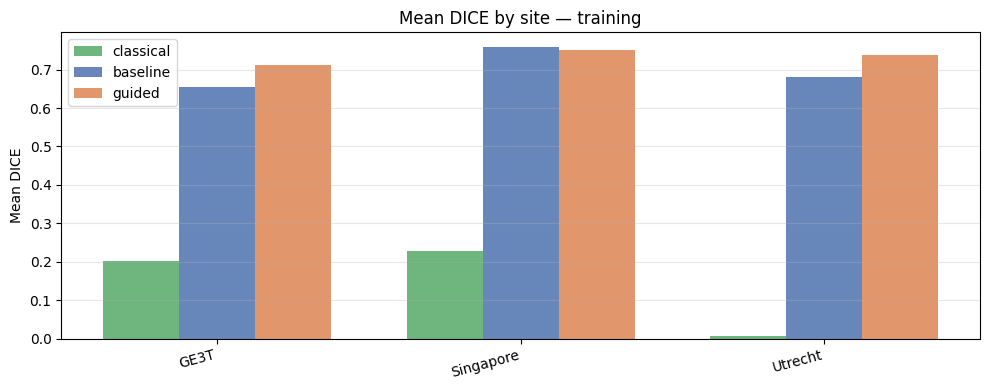


── TEST — mean DICE by site ──
method                           classical  baseline  guided  guided_Δ
site                                                                  
Amsterdam/GE1T5                     0.2582    0.6095  0.6677    0.0582
Amsterdam/GE3T                      0.3002    0.6090  0.6796    0.0706
Amsterdam/Philips_VU .PETMR_01.     0.1995    0.6204  0.6916    0.0712
Singapore                           0.1894    0.6949  0.7292    0.0343
Utrecht                             0.0052    0.6292  0.6814    0.0522


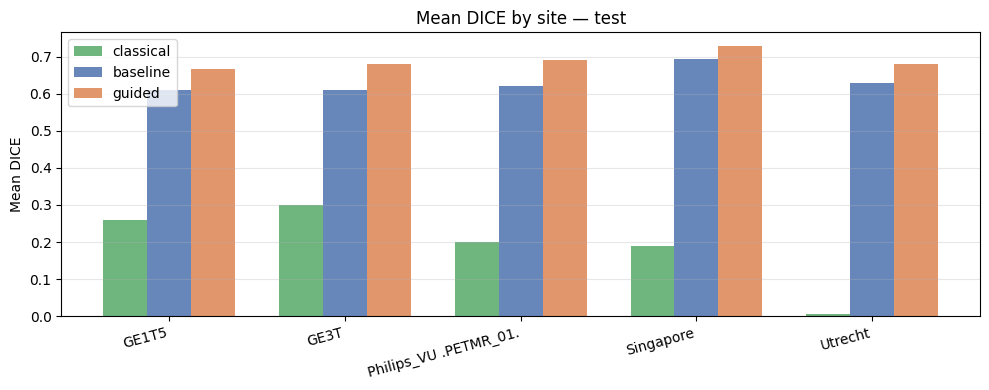

In [15]:
for split, df in [('training', train_df), ('test', test_df)]:
    if df.empty: continue
    print(f'\n── {split.upper()} — mean DICE by site ──')
    pivot = df.groupby(['site','method'])['dice'].mean().unstack('method').round(4)
    for col in ['classical','baseline','guided']:
        if col not in pivot.columns: pivot[col] = float('nan')
    pivot = pivot[['classical','baseline','guided']]
    pivot['guided_Δ'] = (pivot['guided'] - pivot['baseline']).round(4)
    print(pivot.to_string())

    fig, ax = plt.subplots(figsize=(10, 4))
    sites   = [s.split('/')[-1] for s in pivot.index]
    x, w    = np.arange(len(sites)), 0.25
    for i, (m, c) in enumerate([('classical',COL['classical']),
                                  ('baseline', COL['baseline']),
                                  ('guided',   COL['guided'])]):
        ax.bar(x + i*w - w, pivot[m].values, w, label=m, color=c, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(sites, rotation=15, ha='right')
    ax.set_ylabel('Mean DICE')
    ax.set_title(f'Mean DICE by site — {split}')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    #plt.savefig(OUT_DIR/f'dice_by_site_{split}.png', dpi=150, bbox_inches='tight')
    plt.show()